In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import matplotlib.patches as mpl_patches
from scipy.stats import spearmanr

In [8]:
df = pd.read_csv('810_Mg_blues_top3SNPs_wCoordinates_variables.csv')
df

,Accession_ID,Mg_blues,chr5_21392702,chr5_21405867,chr5_282011,Latitude,Longitude,bio1,bio2,bio3,...,K,N,P,ph,sand,silt,srad_mean,ai,GRIDCODE,CLASSLIMIT
0,88,4381.237684,0,0,1,47.4000,0.683333,11.829166,8.825000,37.875538,...,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.833008,0.6404,38.0,44.8 - 48.2 mg/kg
1,108,4249.456382,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
2,139,4489.038748,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
3,159,4812.735886,0,.,1,47.3500,3.933330,9.325000,7.700000,32.352940,...,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.916992,0.9524,29.0,23.2 - 25.0 mg/kg
4,265,3798.743649,0,1,1,44.6500,-1.166670,12.962500,9.558333,42.293510,...,237.268997,2.043349,10.124886,5.435710,70.752350,17.501411,12972.333008,0.9147,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,9933,5149.871903,0,0,1,43.7400,3.890000,14.079166,9.141666,35.296009,...,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.000000,0.4689,44.0,69.5 - 74.8 mg/kg
806,9938,4967.209695,0,0,1,50.6500,2.990000,10.345834,7.675000,34.417042,...,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.666992,0.8376,36.0,38.7 - 41.7 mg/kg
807,10020,5158.205468,1,0,1,49.1700,16.500000,8.854167,8.458333,29.994089,...,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.916992,0.5385,53.0,134 - 144 mg/kg
808,10022,4467.362925,0,1,1,48.0333,7.766700,10.783334,8.466667,32.816536,...,208.210236,2.711020,36.571175,6.667569,22.351379,54.793911,11402.500000,0.9392,41.0,55.8 - 60.0 mg/kg


In [9]:
df=df.rename(columns={'coarse_fragments':'coarse frag',
                      'bulk_density':'bulk density',
                      'CaCO3':'CaCO$_3$',
                      'ai':'AI',
                      'awc':'AWC',
                      'GRIDCODE':'Mg(Soil)',
                      'Mg_blues':'Mg(Leaf)',
                      'srad_mean':'srad',
                      'ph':'pH'
                     })
df

,Accession_ID,Mg(Leaf),chr5_21392702,chr5_21405867,chr5_282011,Latitude,Longitude,bio1,bio2,bio3,...,K,N,P,pH,sand,silt,srad,AI,Mg(Soil),CLASSLIMIT
0,88,4381.237684,0,0,1,47.4000,0.683333,11.829166,8.825000,37.875538,...,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.833008,0.6404,38.0,44.8 - 48.2 mg/kg
1,108,4249.456382,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
2,139,4489.038748,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
3,159,4812.735886,0,.,1,47.3500,3.933330,9.325000,7.700000,32.352940,...,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.916992,0.9524,29.0,23.2 - 25.0 mg/kg
4,265,3798.743649,0,1,1,44.6500,-1.166670,12.962500,9.558333,42.293510,...,237.268997,2.043349,10.124886,5.435710,70.752350,17.501411,12972.333008,0.9147,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,9933,5149.871903,0,0,1,43.7400,3.890000,14.079166,9.141666,35.296009,...,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.000000,0.4689,44.0,69.5 - 74.8 mg/kg
806,9938,4967.209695,0,0,1,50.6500,2.990000,10.345834,7.675000,34.417042,...,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.666992,0.8376,36.0,38.7 - 41.7 mg/kg
807,10020,5158.205468,1,0,1,49.1700,16.500000,8.854167,8.458333,29.994089,...,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.916992,0.5385,53.0,134 - 144 mg/kg
808,10022,4467.362925,0,1,1,48.0333,7.766700,10.783334,8.466667,32.816536,...,208.210236,2.711020,36.571175,6.667569,22.351379,54.793911,11402.500000,0.9392,41.0,55.8 - 60.0 mg/kg


In [10]:
df=df.drop(columns=['chr5_21392702',
                    'chr5_21405867',
                    'chr5_282011',
                    'CLASSLIMIT',
                    'Accession_ID'])
df

,Mg(Leaf),Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,bio7,...,coarse frag,K,N,P,pH,sand,silt,srad,AI,Mg(Soil)
0,4381.237684,47.4000,0.683333,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,23.299999,...,15.149744,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.833008,0.6404,38.0
1,4249.456382,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0
2,4489.038748,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0
3,4812.735886,47.3500,3.933330,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,23.800001,...,25.592224,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.916992,0.9524,29.0
4,3798.743649,44.6500,-1.166670,12.962500,9.558333,42.293510,483.411774,25.200001,2.6,22.600000,...,7.823430,237.268997,2.043349,10.124886,5.435710,70.752350,17.501411,12972.333008,0.9147,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,5149.871903,43.7400,3.890000,14.079166,9.141666,35.296009,605.116272,28.400000,2.5,25.900000,...,21.798716,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.000000,0.4689,44.0
806,4967.209695,50.6500,2.990000,10.345834,7.675000,34.417042,542.320190,23.100000,0.8,22.300001,...,6.823482,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.666992,0.8376,36.0
807,5158.205468,49.1700,16.500000,8.854167,8.458333,29.994089,755.646790,24.200001,-4.0,28.200001,...,9.075080,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.916992,0.5385,53.0
808,4467.362925,48.0333,7.766700,10.783334,8.466667,32.816536,660.266235,25.200001,-0.6,25.800001,...,9.125873,208.210236,2.711020,36.571175,6.667569,22.351379,54.793911,11402.500000,0.9392,41.0


In [11]:
df=df.dropna()
df

,Mg(Leaf),Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,bio7,...,coarse frag,K,N,P,pH,sand,silt,srad,AI,Mg(Soil)
0,4381.237684,47.4000,0.683333,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,23.299999,...,15.149744,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.833008,0.6404,38.0
1,4249.456382,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0
2,4489.038748,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0
3,4812.735886,47.3500,3.933330,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,23.800001,...,25.592224,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.916992,0.9524,29.0
5,5330.870503,46.6667,4.116670,10.720833,9.175000,35.562016,621.583252,25.400000,-0.4,25.799999,...,12.934365,237.669601,1.743629,36.619621,6.276878,31.822845,43.187374,12031.583008,0.7753,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,5226.664196,48.9100,4.520000,10.491667,9.450000,36.914062,595.848633,25.299999,-0.3,25.599998,...,15.485302,288.782288,1.758133,48.285244,7.874985,22.354774,48.579197,11090.416992,0.7287,32.0
805,5149.871903,43.7400,3.890000,14.079166,9.141666,35.296009,605.116272,28.400000,2.5,25.900000,...,21.798716,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.000000,0.4689,44.0
806,4967.209695,50.6500,2.990000,10.345834,7.675000,34.417042,542.320190,23.100000,0.8,22.300001,...,6.823482,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.666992,0.8376,36.0
807,5158.205468,49.1700,16.500000,8.854167,8.458333,29.994089,755.646790,24.200001,-4.0,28.200001,...,9.075080,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.916992,0.5385,53.0


In [31]:
df=df.loc[(df['Latitude']>36.52) & 
             (df['Latitude']<68.80) & 
             (df['Longitude']>-8.54) & 
             (df['Longitude']<38.28)]
df

,Mg(Leaf),Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,bio7,...,coarse frag,K,N,P,pH,sand,silt,srad,AI,Mg(Soil)
0,4381.237684,47.4000,0.683333,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,23.299999,...,15.149744,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.833008,0.6404,38.0
1,4249.456382,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0
2,4489.038748,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0
3,4812.735886,47.3500,3.933330,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,23.800001,...,25.592224,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.916992,0.9524,29.0
5,5330.870503,46.6667,4.116670,10.720833,9.175000,35.562016,621.583252,25.400000,-0.4,25.799999,...,12.934365,237.669601,1.743629,36.619621,6.276878,31.822845,43.187374,12031.583008,0.7753,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,5226.664196,48.9100,4.520000,10.491667,9.450000,36.914062,595.848633,25.299999,-0.3,25.599998,...,15.485302,288.782288,1.758133,48.285244,7.874985,22.354774,48.579197,11090.416992,0.7287,32.0
805,5149.871903,43.7400,3.890000,14.079166,9.141666,35.296009,605.116272,28.400000,2.5,25.900000,...,21.798716,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.000000,0.4689,44.0
806,4967.209695,50.6500,2.990000,10.345834,7.675000,34.417042,542.320190,23.100000,0.8,22.300001,...,6.823482,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.666992,0.8376,36.0
807,5158.205468,49.1700,16.500000,8.854167,8.458333,29.994089,755.646790,24.200001,-4.0,28.200001,...,9.075080,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.916992,0.5385,53.0


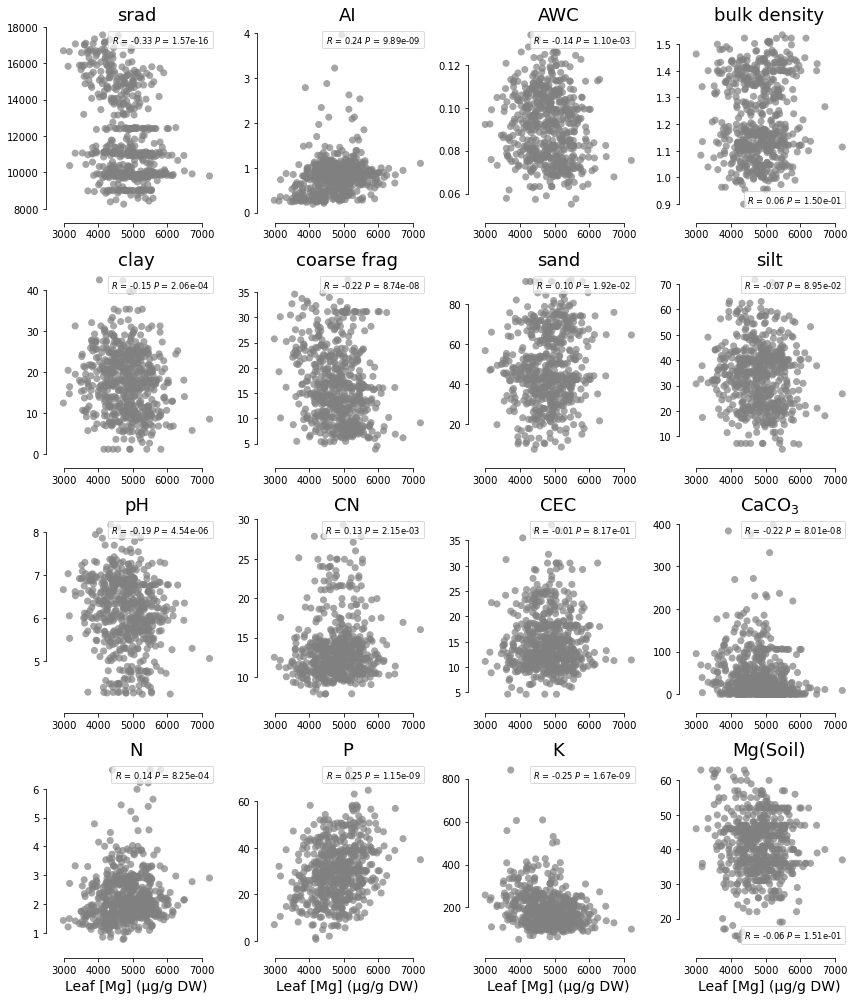

In [32]:
other=['srad','AI','AWC',
       'bulk density','clay','coarse frag',
       'sand','silt','pH','CN','CEC',
       'CaCO$_3$','N','P','K', 'Mg(Soil)']

def plots(var,idx1,idx2):
    sns.scatterplot(x='Mg(Leaf)',
                    y=var,
                    color='grey',
                    edgecolor='none',
                    marker='o',
                    s=50,
                    alpha=0.7,
                    data=df,
                    ax=axes[idx1,idx2])

    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
    labels = []
    r,p = spearmanr(df[var],df['Mg(Leaf)'])
    labels.append(r"$\itR$ = {:.2f} $P$ = {:.2e}".format(r,p))
    axes[idx1,idx2].legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)
    axes[idx1,idx2].set_xlabel('')
    axes[idx1,idx2].set_ylabel('')
    axes[idx1,idx2].set_title(var,fontsize=18)
    axes[idx1,idx2].xaxis.set_major_locator(ticker.MultipleLocator(1000))
    
    
fig,axes = plt.subplots(4,4,sharey=False,figsize=(12,14))
a,b=0,0
# for index, value in enumerate(elements):
for index in range(len(other)):
    if index % 4 == 0:
        if index == 0:
            plots(other[index],a,b)
            b+=1
        elif index == 12:
            a+=1
            b=0
            plots(other[index],a,b)
            axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
            b+=1
        else:
            a+=1
            b=0
            plots(other[index],a,b)
            b+=1
    elif index > 12: 
        plots(other[index],a,b)
        axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
        b+=1
    else:
        plots(other[index],a,b)
        b+=1
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.savefig("FigS3.pdf", format="pdf",bbox_inches="tight",facecolor="w")